# Forecasting using RNN networks

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from keras.models import Sequential
from keras.layers import GRU, Dropout, SimpleRNN, Dense, LSTM
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau 

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## Import Data

In [2]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv", 
                   index_col=0, 
                   parse_dates=True) # set index to datetime 

## ARIMA model - baseline 

In [3]:
# !pip install --upgrade numpy==1.26.4

In [4]:
# Apply First Differencing to remove the trend 
data['close_diff'] = data['close'].diff().dropna()

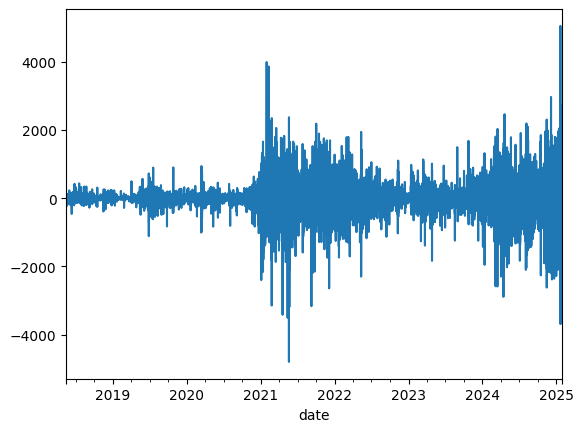

In [5]:
data['close_diff'].plot();

In [6]:
# Check if data is stationary 
from statsmodels.tsa.stattools import adfuller

# ADF Test after first differencing
result_diff = adfuller(data['close_diff'].dropna())

print(f"ADF Test Statistic (Differenced): {result_diff[0]}")
print(f"p-value (Differenced): {result_diff[1]}")
print("Critical Values:")
for key, value in result_diff[4].items():
    print(f"{key}: {value}")

# Check stationarity
if result_diff[1] > 0.05:
    print("The differenced series is NON-STATIONARY. Consider second differencing.")
else:
    print("The differenced series is STATIONARY.")

ADF Test Statistic (Differenced): -30.94015531837786
p-value (Differenced): 0.0
Critical Values:
1%: -3.4304612496058677
5%: -2.8615891702029366
10%: -2.566796171644624
The differenced series is STATIONARY.


In [7]:
# Figure out Order for ARIMA model 
from pmdarima import auto_arima
# Ignore harmless warnings 
import warnings
warnings.filterwarnings("ignore")

In [8]:
stepwise_fit = auto_arima(data['close_diff'].dropna(), trace=True, suppress_warnings=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=816170.511, Time=11.59 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=816182.668, Time=0.46 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=816173.423, Time=0.65 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=816173.259, Time=0.92 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=816183.143, Time=0.22 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=816174.047, Time=2.08 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=816174.041, Time=1.85 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=816177.974, Time=3.44 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=816170.827, Time=7.59 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=816166.138, Time=4.54 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=816172.089, Time=1.29 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=816172.242, Time=0.71 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=816166.831, Time=1.46 sec

Best model:  ARIMA(1,0,1)(0,0,0)[0] intercept
Total fit time: 36.833 se

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                58842
Model:               SARIMAX(1, 0, 1)   Log Likelihood             -408079.069
Date:                Sat, 01 Feb 2025   AIC                         816166.138
Time:                        16:00:36   BIC                         816202.069
Sample:                    05-15-2018   HQIC                        816177.309
                         - 01-30-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.5400      0.348      1.554      0.120      -0.141       1.221
ar.L1          0.6692      0.057     11.787      0.000       0.558       0.780
ma.L1         -0.6831      0.056    -12.219      0.000      -0.793      -0.574
sigma2      6.186e+04     96.110    643.585      0.000    6.17e+04     6.2e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           1747322.16
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):              23.47   Skew:                            -0.33
Prob(H) (two-sided):                  0.00   Kurtosis:                        29.69
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
from statsmodels.tsa.arima.model import ARIMA

In [10]:
# Split data 
print(data.shape)
arima_train = data.iloc[:47074]
arima_test = data.iloc[47074:]
print(arima_train.shape, arima_test.shape)

(58843, 5)
(47074, 5) (11769, 5)


In [11]:
arima_train.dropna(inplace=True)
arima_train

,open,high,low,close,close_diff
date,,,,,
2018-05-15 07:00:00,8740.99,8766.00,8721.11,8739.00,-1.99
2018-05-15 08:00:00,8739.00,8750.27,8660.53,8728.49,-10.51
2018-05-15 09:00:00,8728.49,8754.40,8701.35,8708.32,-20.17
2018-05-15 10:00:00,8708.32,8865.00,8695.11,8795.90,87.58
2018-05-15 11:00:00,8795.90,8821.19,8740.54,8760.00,-35.90
...,...,...,...,...,...
2023-09-27 11:00:00,26425.00,26817.00,26425.00,26749.00,322.00
2023-09-27 12:00:00,26759.00,26823.00,26673.00,26702.00,-47.00
2023-09-27 13:00:00,26712.00,26791.00,26554.00,26610.00,-92.00


In [12]:
# Train the model 
arima_model = ARIMA(arima_train['close_diff'], order=(1,0,1))
arima_model = arima_model.fit()
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             close_diff   No. Observations:                47073
Model:                 ARIMA(1, 0, 1)   Log Likelihood             -318418.722
Date:                Sat, 01 Feb 2025   AIC                         636845.444
Time:                        16:00:38   BIC                         636880.482
Sample:                    05-15-2018   HQIC                        636856.450
                         - 09-27-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3725      0.970      0.384      0.701      -1.529       2.274
ar.L1          0.1032      0.196      0.526      0.599      -0.282       0.488
ma.L1         -0.1126      0.196     -0.574      0.566      -0.497       0.272
sigma2      4.396e+04     67.999    646.428      0.000    4.38e+04    4.41e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.16   Jarque-Bera (JB):           2335355.68
Prob(Q):                              0.69   Prob(JB):                         0.00
Heteroskedasticity (H):               9.66   Skew:                            -0.51
Prob(H) (two-sided):                  0.00   Kurtosis:                        37.49
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
# Make predictions on test set
start = len(arima_train)
end = len(arima_train)+len(arima_test)-1
arima_pred = arima_model.predict(start=start, end=end, type='levels')
print(arima_pred)

2023-09-27 16:00:00   -0.089360
2023-09-27 17:00:00    0.324880
2023-09-27 18:00:00    0.367613
2023-09-27 19:00:00    0.372021
2023-09-27 20:00:00    0.372476
                         ...   
2025-01-29 20:00:00    0.372528
2025-01-29 21:00:00    0.372528
2025-01-29 22:00:00    0.372528
2025-01-29 23:00:00    0.372528
2025-01-30 00:00:00    0.372528
Freq: h, Name: predicted_mean, Length: 11769, dtype: float64


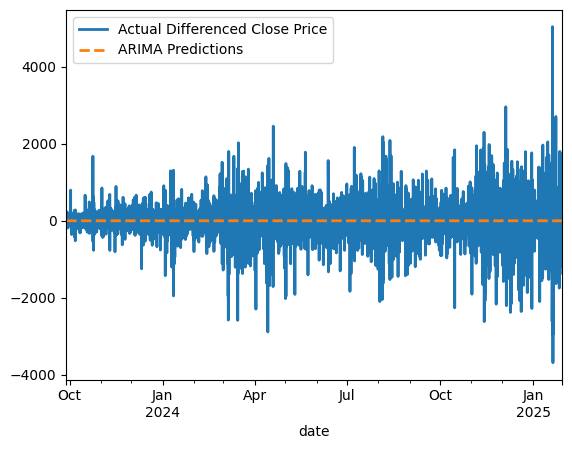

In [14]:
# Plot
arima_test['close_diff'].plot(label="Actual Differenced Close Price", legend=True, linewidth=2)
arima_pred.plot(label="ARIMA Predictions", linestyle="dashed", legend=True, linewidth=2);

In [15]:
arima_test['close_diff'].mean()

6.5765145721811535

In [16]:
# Evaluate 
from math import sqrt 
arima_RMSE = sqrt(mean_squared_error(arima_pred, arima_test['close_diff']))
print(arima_RMSE)

365.42553728916494


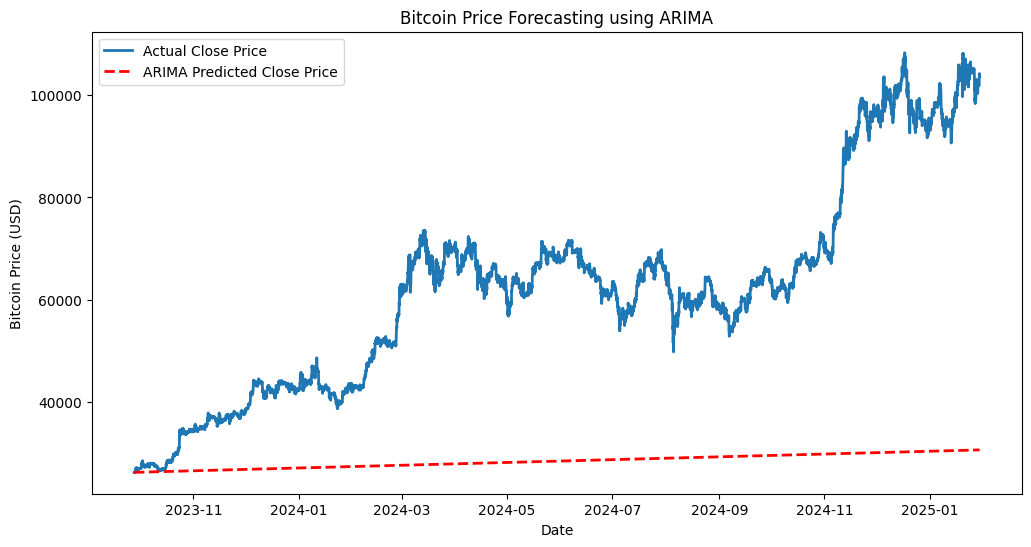

In [17]:
# Get the last actual closing price before the test set
last_train_close = arima_train['close'].iloc[-1]

# Convert differenced predictions back to actual close prices
arima_pred_close = last_train_close + arima_pred.cumsum()

# Plot actual vs predicted closing prices
plt.figure(figsize=(12, 6))
plt.plot(arima_test.index, arima_test['close'], label="Actual Close Price", linewidth=2)
plt.plot(arima_pred_close.index, arima_pred_close, label="ARIMA Predicted Close Price", linestyle="dashed", linewidth=2, color='red')

plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.title("Bitcoin Price Forecasting using ARIMA")
plt.legend()
plt.show()

## Prepare Data for the RNNs

In [ ]:
# Normalize the data 
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

In [ ]:
def create_sequences(data, window_size, target_col_idx):
    """
    data: NumPy array with all features (open, high, low, close)
    window_size: Number of past time steps to use
    target_col_idx: Index of the column to predict (close price = -1)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])  # Take all columns as input
        y.append(data[i + window_size, target_col_idx])  # Only the close price as output
    return np.array(X), np.array(y)

window_size = 15

target_col_idx = data.columns.get_loc("close")
X, y = create_sequences(data_normalized, window_size, target_col_idx=target_col_idx)
X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))  # Keep all features

### Split

In [ ]:
split = int(len(X) * 0.8)  # 80% training, 20% testing
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

## Implementing GRU

In [ ]:
gru_model = Sequential()

# First GRU layer with dropout
gru_model.add(GRU(30, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
gru_model.add(Dropout(0.5))

# Fourth GRU layer (should NOT return sequences)
gru_model.add(GRU(30, return_sequences=False))  # << FIXED
gru_model.add(Dropout(0.5))

# Output layer: predicting only the close prices (1 feature)
gru_model.add(Dense(1))

# Define Learning Rate Decay
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

# Compile the model (fix optimizer issue)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
gru_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
gru_model.summary()

# Define Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

# Train the GRU model with Early Stopping
history = gru_model.fit(X_train, y_train, 
                        epochs=50,  # Increased epochs
                        batch_size=256, 
                        validation_data=(X_test, y_test), 
                        callbacks=[early_stopping],  
                        verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Make predictions
predicted_gru = gru_model.predict(X_test)

# Inverse transform predictions
predicted_gru = close_scaler.inverse_transform(predicted_gru.reshape(-1, 1))
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute error metrics
mae = mean_absolute_error(y_test_actual, predicted_gru)
mse = mean_squared_error(y_test_actual, predicted_gru)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_gru) / y_test_actual)) * 100  
r2 = r2_score(y_test_actual, predicted_gru)

# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

# Ensure the date index is in datetime format
date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_gru, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Implementing LSTM

In [ ]:
# LSTM Model (Fixed Version)
lstm_model = Sequential()

# First LSTM layer with dropout
lstm_model.add(LSTM(30, return_sequences=True, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(Dropout(0.5))  # Increased dropout for consistency with GRU

# Fourth LSTM layer with dropout (return_sequences=False)
lstm_model.add(LSTM(30, return_sequences=False, recurrent_dropout=0.2))  # Fixed shape issue
lstm_model.add(Dropout(0.5))

# Output layer
lstm_model.add(Dense(1))

# Define Learning Rate Decay
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

# Compile the model (Fixed Optimizer Issue)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
lstm_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
lstm_model.summary()

# Define Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

# Train the LSTM model with Early Stopping
history = lstm_model.fit(X_train, y_train, 
                        epochs=50,  # Increased for better learning
                        batch_size=256,  # Increased for smoother validation loss
                        validation_data=(X_test, y_test), 
                        callbacks=[early_stopping],  
                        verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (LSTM Model)')
plt.legend()
plt.grid(True)
plt.show()

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Make predictions
predicted_lstm = lstm_model.predict(X_test)

# Inverse transform predictions
predicted_lstm = close_scaler.inverse_transform(predicted_lstm.reshape(-1, 1))
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute error metrics
mae = mean_absolute_error(y_test_actual, predicted_lstm)
mse = mean_squared_error(y_test_actual, predicted_lstm)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_lstm) / y_test_actual)) * 100  
r2 = r2_score(y_test_actual, predicted_lstm)

# Print results
print(f"Model Error Statistics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

# Ensure the date index is in datetime format
date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_lstm, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (LSTM Model)')
plt.xlabel('Date')
plt.ylabel('Price')

# Format x-axis to show Month-Year
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Hybrid LSTM-GRU model

In [ ]:
# Hybrid LSTM-GRU Model
hybrid_model = Sequential()

# First LSTM layer with recurrent dropout
hybrid_model.add(LSTM(32, return_sequences=True, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2])))
hybrid_model.add(Dropout(0.5))

# First GRU layer (return_sequences=False to avoid shape issues)
hybrid_model.add(GRU(32, return_sequences=False, recurrent_dropout=0.2))  
hybrid_model.add(Dropout(0.5))

# Output layer
hybrid_model.add(Dense(1))

# Define Learning Rate Decay
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  # Start with a small learning rate
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
hybrid_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
hybrid_model.summary()

# Define Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

# Train the Hybrid Model
history_hybrid = hybrid_model.fit(X_train, y_train, 
                                  epochs=50,  
                                  batch_size=256,  # Increased batch size for stability
                                  validation_data=(X_test, y_test), 
                                  callbacks=[early_stopping],  
                                  verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history_hybrid.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_hybrid.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Hybrid Model)')
plt.legend()
plt.grid(True)
plt.show()

# Make predictions
predicted_hybrid = hybrid_model.predict(X_test)

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Inverse transform the predicted and actual values using the correct scaler
predicted_hybrid = close_scaler.inverse_transform(predicted_hybrid.reshape(-1, 1))  # Fixed reshaping issue
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluate model performance
mae = mean_absolute_error(y_test_actual, predicted_hybrid)
mse = mean_squared_error(y_test_actual, predicted_hybrid)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_hybrid) / y_test_actual)) * 100  
r2 = r2_score(y_test_actual, predicted_hybrid)

# Print results
print(f"Hybrid Model Error Statistics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

# Plot Actual vs Predicted Prices
date_index = pd.to_datetime(data.index[-len(y_test_actual):])
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_hybrid, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (Hybrid LSTM-GRU Model)')
plt.xlabel('Date')
plt.ylabel('Price')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()